In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats

In [29]:
loan_applications = pd.read_csv("loan_applications.csv")
print(loan_applications.head())

   Customer_ID  Age  Income  Loan_Amount  Credit_Score  Loan_Term_Months  \
0            1   59   10751         1728           737                60   
1            2   49   12982         5248           502                60   
2            3   35   17746         8010           693                24   
3            4   63   48161        15718           605                24   
4            5   28   19469         4315           715                24   

  Default_Status  
0            Yes  
1             No  
2             No  
3             No  
4             No  


In [ ]:
mean_income = loan_applications["Income"].mean()
median_income = loan_applications["Income"].median()
mode_income = loan_applications["Income"].mode()[0]

print(f"mean income is:- {mean_income}")
print(f"median income is:- {median_income}")
print(f"mode income is:- {mode_income}")

mean income is:- 24931.744
median income is:- 22067.5
mode income is:- 13107


In [ ]:
range_loan_amount = loan_applications["Loan_Amount"].max() - loan_applications["Loan_Amount"].min()
variance_loan_amount = loan_applications["Loan_Amount"].var()
standard_deviation_loan_amount = loan_applications["Loan_Amount"].std()

print(f"range of loan amount is:- {range_loan_amount}")
print(f"variance of loan amount is:- {variance_loan_amount}")
print(f"standard deviation of loan amount is:- {standard_deviation_loan_amount}")

range of loan amount is:- 49289
variance of loan amount is:- 36470384.53937312
standard deviation of loan amount is:- 6039.071496461449


In [32]:
# Probability and events

p_loan_default = (loan_applications["Default_Status"] == "Yes").mean()
print(f"probability of loan default is:- {p_loan_default}")

probability of loan default is:- 0.2534


In [33]:
loan_applications["Credit_Category"] = pd.cut(
    loan_applications["Credit_Score"],
    bins=[300, 500, 600, 700, 800, 850],
    labels=["Poor", "Fair", "Good", "Very Good", "Excellent"]
)
contingency_table = pd.crosstab(loan_applications["Credit_Category"], loan_applications["Default_Status"])
print(contingency_table)

Default_Status     No  Yes
Credit_Category           
Poor               46   95
Fair              478  747
Good             2083  270
Very Good        1001  139
Excellent         125   16


In [34]:

default_status_yes= loan_applications["Default_Status"] == "Yes"
credit_score_less_600 = loan_applications["Credit_Score"] < 600

intersection = len(loan_applications[default_status_yes & credit_score_less_600]) / len(loan_applications)

p_credit_score_less_600 = len(loan_applications[credit_score_less_600]) / len(loan_applications)

conditional_prob = intersection / p_credit_score_less_600

print("P(Default | Credit Score < 600) =", conditional_prob)

P(Default | Credit Score < 600) = 0.6235119047619048


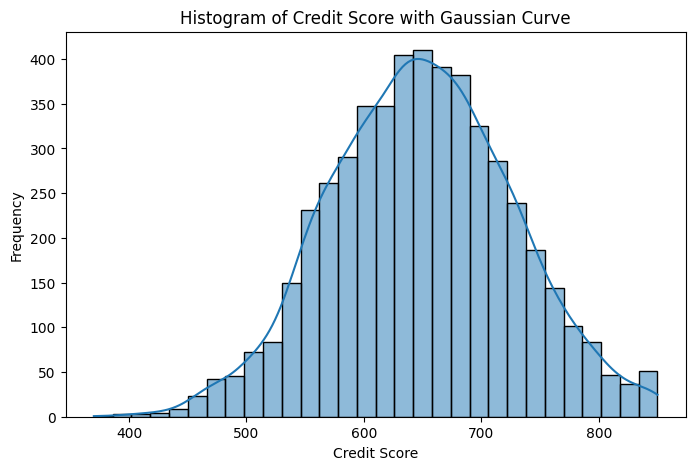

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(loan_applications["Credit_Score"], kde=True, bins=30)
plt.title("Histogram of Credit Score with Gaussian Curve")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()
plt.savefig("Histogram of Credit Score with Gaussian Curve.png",dpi=300)

In [37]:
skewness = stats.skew(loan_applications["Loan_Amount"])
kurtosis = stats.kurtosis(loan_applications["Loan_Amount"])

print(f"Skewness of Loan Amount:{skewness}")
print(f"Kurtosis of Loan Amount:{kurtosis}")

Skewness of Loan Amount:1.8270302473399738
Kurtosis of Loan Amount:5.385520933612581


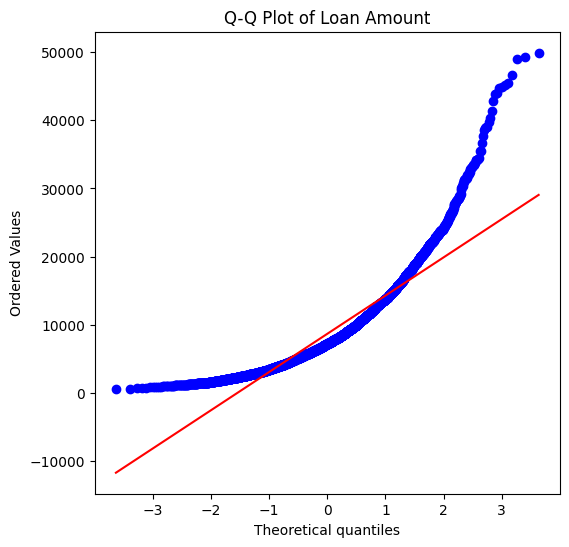

<Figure size 640x480 with 0 Axes>

In [38]:
plt.figure(figsize=(6,6))
stats.probplot(loan_applications["Loan_Amount"], dist="norm", plot=plt)
plt.title("Q-Q Plot of Loan Amount")
plt.show()
plt.savefig("Q-Q Plot of Loan Amount",dpi=300)

In [ ]:
vectors = loan_applications[["Income","Loan_Amount"]].head(5).values

v1 = vectors[0]
v2 = vectors[1]

print("Vector 1:", v1)
print("Vector 2:", v2)

Vector 1: [10751  1728]
Vector 2: [12982  5248]


In [40]:
dot_product = np.dot(v1, v2)
print(f"Dot Product: {dot_product}")

Dot Product: 148638026


In [41]:
norm_v1 = np.linalg.norm(v1)
norm_v2 = np.linalg.norm(v2)

print("Norm of Vector 1:", norm_v1)
print("Norm of Vector 2:", norm_v2)

Norm of Vector 1: 10888.984571575074
Norm of Vector 2: 14002.636466037387


In [42]:
angle = np.arccos(dot_product / (norm_v1 * norm_v2))

print("Angle between vectors (radians):", angle)
print("Angle between vectors (degrees):", np.degrees(angle))


Angle between vectors (radians): 0.22480033370543553
Angle between vectors (degrees): 12.880110354453963


In [43]:
print("\n===== BUSINESS INSIGHTS =====")

print("1. Customers with low credit scores have higher probability of default.")
print("2. Loan amounts show positive skewness indicating some customers take very high loans.")
print("3. Distribution of credit score is approximately normal.")
print("4. Higher loan relative to income increases financial risk.")
print("5. Statistical analysis helps banks predict potential loan defaults.")


===== BUSINESS INSIGHTS =====
1. Customers with low credit scores have higher probability of default.
2. Loan amounts show positive skewness indicating some customers take very high loans.
3. Distribution of credit score is approximately normal.
4. Higher loan relative to income increases financial risk.
5. Statistical analysis helps banks predict potential loan defaults.
